<a href="https://colab.research.google.com/github/Yaroslavwvw/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9F%D0%BE%D1%81%D1%82%D1%80%D0%BE%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%BE%D0%B9_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D0%BE%D0%B9_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_%D0%B4%D0%BB%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9%2C_%D1%81_%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%D0%BC_BatchNormalization()_%D0%B8_Dropout().ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()

[Код с пары](https://colab.research.google.com/drive/1cvPrPI09ySQy-D92gKTzmanVi2cj5Gw_?usp=sharing)

## Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():

### 1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:

*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете в Kaggle](https://www.kaggle.com/datasets/fedesoriano/cifar100?resource=download&select=meta)

[Техническая документация по использованию датасета в Keras](https://keras.io/api/datasets/cifar100/)





In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

# Загрузка данных
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Проверка размерности
print("Train data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


### 1.2. Визуализируйте несколько изображений из датасета:


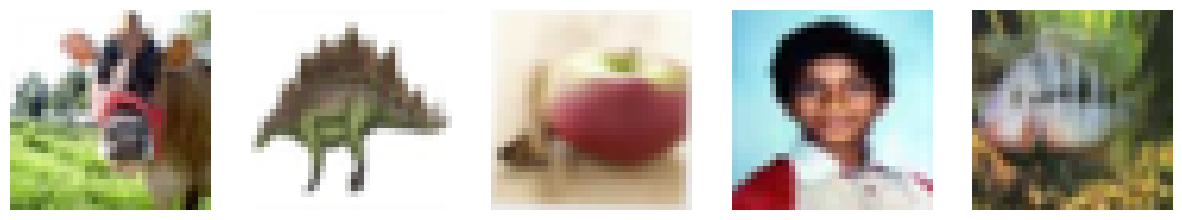

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()

### 1.3. Произведите нормализацию данных:

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### 1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():

Имя данной модели: model_1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(100, activation='softmax')
])

model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Обучите созданную модель

In [ ]:
history_1 = model_1.fit(x_train, y_train,
                        epochs=50,
                        validation_data=(x_test, y_test),
                        batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.1510 - loss: 3.6626 - val_accuracy: 0.2323 - val_loss: 3.1832
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2856 - loss: 2.9072 - val_accuracy: 0.3023 - val_loss: 2.8092
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3531 - loss: 2.5696 - val_accuracy: 0.3410 - val_loss: 2.6498
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4008 - loss: 2.3393 - val_accuracy: 0.3544 - val_loss: 2.5930
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4412 - loss: 2.1526 - val_accuracy: 0.3680 - val_loss: 2.5355
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4742 - loss: 1.9967 - val_accuracy: 0.3835 - val_loss: 2.4667
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5083 - loss: 1.8500 - val_accuracy: 0.3784 - val_loss: 2.5227
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5422 - loss: 1.7049 - val_accuracy: 0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

model_1_1 = Sequential([
    Input(shape=(32, 32, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',),
    Conv2D(32, (3,3), activation='relu', padding='same',),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same',),
    Conv2D(64, (3,3), activation='relu', padding='same',),
    MaxPooling2D((2,2)),

    # # Block 3 (углубили сеть)
    # Conv2D(128, (3,3), activation='relu', padding='same',),
    # Conv2D(128, (3,3), activation='relu', padding='same',),
    # MaxPooling2D((2,2)),

    # Classifier
    Flatten(),

    Dense(128, activation='relu',),
    Dense(64, activation='relu',),

    Dense(100, activation='softmax')
])

model_1_1.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_1_1 = model_1_1.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test),
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.1364 - loss: 3.6874 - val_accuracy: 0.1923 - val_loss: 3.3585
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2478 - loss: 3.0640 - val_accuracy: 0.2732 - val_loss: 2.9319
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3165 - loss: 2.7045 - val_accuracy: 0.3236 - val_loss: 2.6609
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3675 - loss: 2.4539 - val_accuracy: 0.3540 - val_loss: 2.5302
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4124 - loss: 2.2536 - val_accuracy: 0.3722 - val_loss: 2.4615
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4519 - loss: 2.0743 - val_accuracy: 0.3876 - val_loss: 2.3916
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4858 - loss: 1.9177 - val_accuracy: 0.3911 - val_loss: 2.4070
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5220 - loss: 1.7708 - val_accuracy: 

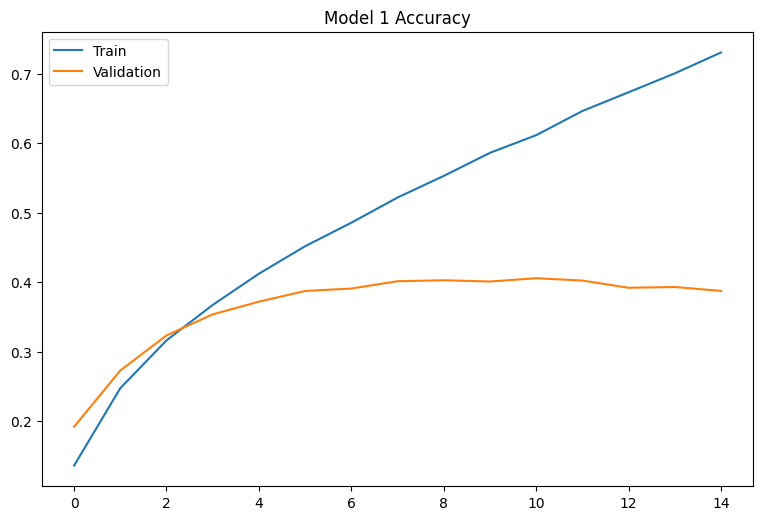

In [ ]:
plt.figure(figsize=(15,10))

# Графики для model_1
plt.subplot(2,2,1)
plt.plot(history_1_1.history['accuracy'], label='Train')
plt.plot(history_1_1.history['val_accuracy'], label='Validation')
plt.title('Model 1 Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

model_1_2 = Sequential([
    Input(shape=(32, 32, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',),
    Conv2D(32, (3,3), activation='relu', padding='same',),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same',),
    Conv2D(64, (3,3), activation='relu', padding='same',),
    MaxPooling2D((2,2)),


    GlobalAveragePooling2D(),

    Dense(128, activation='relu',),
    Dense(64, activation='relu',),

    Dense(100, activation='softmax')
])

model_1_2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_1_2 = model_1_2.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test),
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.0414 - loss: 4.2968 - val_accuracy: 0.0682 - val_loss: 4.0383
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0916 - loss: 3.8873 - val_accuracy: 0.1130 - val_loss: 3.8138
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1241 - loss: 3.6844 - val_accuracy: 0.1411 - val_loss: 3.6081
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1472 - loss: 3.5485 - val_accuracy: 0.1604 - val_loss: 3.4916
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1710 - loss: 3.4260 - val_accuracy: 0.1761 - val_loss: 3.4102
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1886 - loss: 3.3217 - val_accuracy: 0.1909 - val_loss: 3.3151
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.2080 - loss: 3.2184 - val_accuracy: 0.2096 - val_loss: 3.2157
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2257 - loss: 3.1215 - val_accuracy:

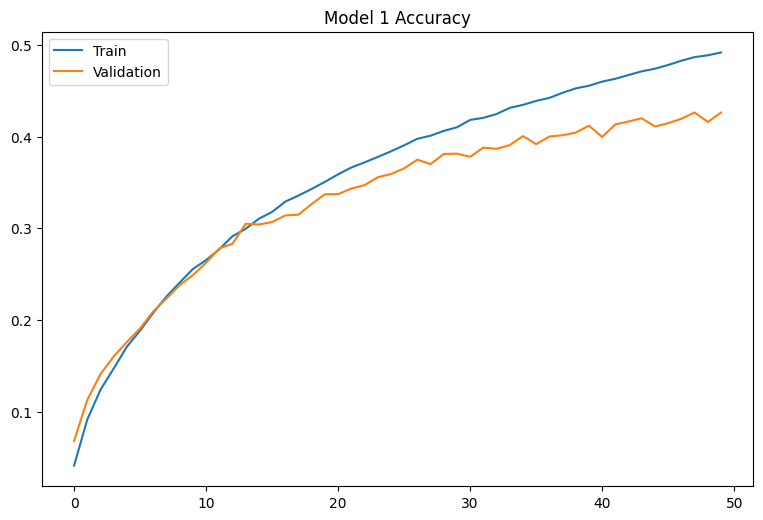

In [ ]:
plt.figure(figsize=(15,10))

# Графики для model_1
plt.subplot(2,2,1)
plt.plot(history_1_2.history['accuracy'], label='Train')
plt.plot(history_1_2.history['val_accuracy'], label='Validation')
plt.title('Model 1 Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

### 1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():

Имя данной модели: model_2

In [ ]:
from tensorflow.keras.layers import BatchNormalization

model_2 = Sequential([
    Conv2D(32, (3,3), use_bias=False, input_shape=(32,32,3)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), use_bias=False),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, use_bias=False),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dense(100, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

Обучите созданную модель

In [ ]:
history_2 = model_2.fit(x_train, y_train,
                        epochs=50,
                        validation_data=(x_test, y_test),
                        batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.1784 - loss: 3.5926 - val_accuracy: 0.2414 - val_loss: 3.1578
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4036 - loss: 2.3651 - val_accuracy: 0.3550 - val_loss: 2.5538
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5037 - loss: 1.9088 - val_accuracy: 0.3617 - val_loss: 2.5916
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5903 - loss: 1.5609 - val_accuracy: 0.3970 - val_loss: 2.4265
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6652 - loss: 1.2597 - val_accuracy: 0.3514 - val_loss: 2.9234
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7343 - loss: 1.0028 - val_accuracy: 0.3653 - val_loss: 2.8757
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7971 - loss: 0.7711 - val_accuracy: 0.3517 - val_loss: 3.1268
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8415 - loss: 0.5971 - val_accuracy: 0.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.layers import Activation, Input

model_2_1 = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(32, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),

    GlobalAveragePooling2D(),

    Dense(128, use_bias=False),
    BatchNormalization(),
    Activation('relu'),

    Dense(100, activation='softmax')
])

model_2_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_2_1 = model_2_1.fit(x_train, y_train,
                        epochs=50,
                        validation_data=(x_test, y_test),
                        batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.1600 - loss: 3.5527 - val_accuracy: 0.1642 - val_loss: 3.5018
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3006 - loss: 2.7254 - val_accuracy: 0.2042 - val_loss: 3.3479
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3850 - loss: 2.3201 - val_accuracy: 0.3202 - val_loss: 2.6766
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4398 - loss: 2.0684 - val_accuracy: 0.3096 - val_loss: 2.7133
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4811 - loss: 1.8984 - val_accuracy: 0.3229 - val_loss: 2.9791
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5160 - loss: 1.7594 - val_accuracy: 0.2813 - val_loss: 3.2341
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5414 - loss: 1.6428 - val_accuracy: 0.3880 - val_loss: 2.4973
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5659 - loss: 1.5433 - val_accuracy:

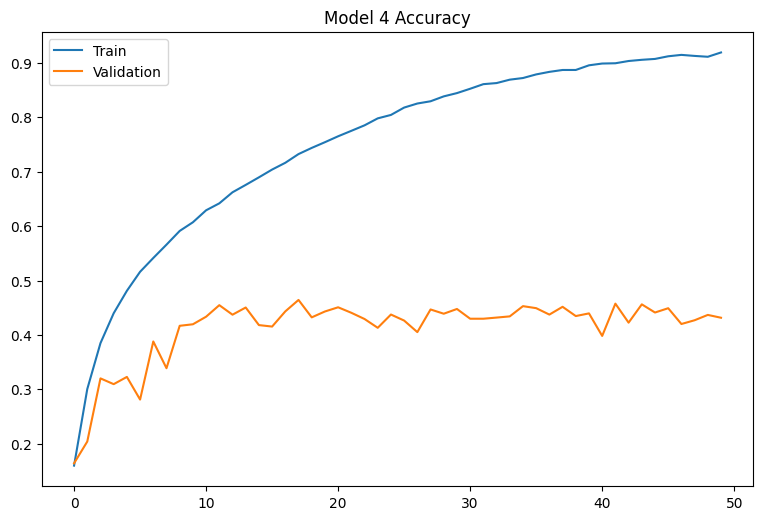

In [ ]:
plt.figure(figsize=(15,10))

# # Графики для model_1
# plt.subplot(2,2,1)
# plt.plot(history_1.history['accuracy'], label='Train')
# plt.plot(history_1.history['val_accuracy'], label='Validation')
# plt.title('Model 1 Accuracy')
# plt.legend()

# # Графики для model_1_1
# plt.subplot(2,2,2)
# plt.plot(history_1_1.history['accuracy'], label='Train')
# plt.plot(history_1_1.history['val_accuracy'], label='Validation')
# plt.title('Model 2 Accuracy')
# plt.legend()

# # Графики для model_1_2
# plt.subplot(2,2,3)
# plt.plot(history_1_2.history['accuracy'], label='Train')
# plt.plot(history_1_2.history['val_accuracy'], label='Validation')
# plt.title('Model 3 Accuracy')
# plt.legend()

# # Графики для model_2
# plt.subplot(2,2,4)
# plt.plot(history_2.history['accuracy'], label='Train')
# plt.plot(history_2.history['val_accuracy'], label='Validation')
# plt.title('Model 4 Accuracy')
# plt.legend()

# Графики для model_2_1
plt.subplot(2,2,4)
plt.plot(history_2_1.history['accuracy'], label='Train')
plt.plot(history_2_1.history['val_accuracy'], label='Validation')
plt.title('Model 4 Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.layers import Activation, Input

model_2_2 = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Activation('relu'),

    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Dense(64, use_bias=False),
    BatchNormalization(),
    Activation('relu'),

    Dense(100, activation='softmax')
])

model_2_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_2_2 = model_2_2.fit(x_train, y_train,
                        epochs=50,
                        validation_data=(x_test, y_test),
                        batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1182 - loss: 3.8535 - val_accuracy: 0.1034 - val_loss: 3.8616
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2131 - loss: 3.2339 - val_accuracy: 0.1167 - val_loss: 3.8828
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2594 - loss: 2.9816 - val_accuracy: 0.1825 - val_loss: 3.4019
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2869 - loss: 2.8337 - val_accuracy: 0.1876 - val_loss: 3.4529
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3092 - loss: 2.7151 - val_accuracy: 0.2144 - val_loss: 3.2554
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3258 - loss: 2.6328 - val_accuracy: 0.2535 - val_loss: 3.0156
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3401 - loss: 2.5636 - val_accuracy: 0.2456 - val_loss: 3.1468
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3524 - loss: 2.5045 - val_accuracy: 0

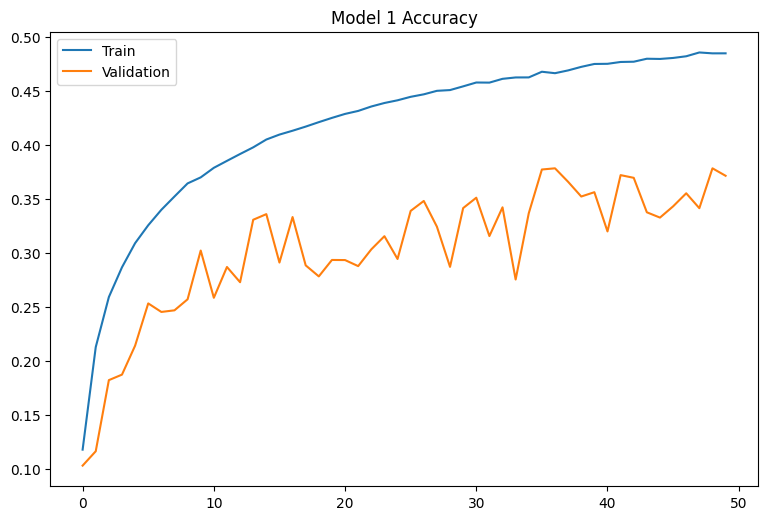

In [ ]:
plt.figure(figsize=(15,10))

# Графики для model_1
plt.subplot(2,2,1)
plt.plot(history_2_2.history['accuracy'], label='Train')
plt.plot(history_2_2.history['val_accuracy'], label='Validation')
plt.title('Model 1 Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

### 1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():

Имя данной модели: model_3

In [ ]:
from tensorflow.keras.layers import Dropout

model_3 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_3.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

Обучите созданную модель

In [ ]:
history_3 = model_3.fit(x_train, y_train,
                        epochs=50,
                        validation_data=(x_test, y_test),
                        batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.0477 - loss: 4.3023 - val_accuracy: 0.1783 - val_loss: 3.5298
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1555 - loss: 3.5580 - val_accuracy: 0.2544 - val_loss: 3.1456
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2130 - loss: 3.2497 - val_accuracy: 0.2898 - val_loss: 2.9405
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2429 - loss: 3.0842 - val_accuracy: 0.3175 - val_loss: 2.8072
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2699 - loss: 2.9647 - val_accuracy: 0.3346 - val_loss: 2.6941
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2852 - loss: 2.8758 - val_accuracy: 0.3495 - val_loss: 2.6243
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2946 - loss: 2.8096 - val_accuracy: 0.3578 - val_loss: 2.6014
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3094 - loss: 2.7397 - val_accuracy: 0

### 1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [ ]:
model_4 = Sequential([
    Conv2D(32, (3,3), use_bias=False, input_shape=(32,32,3)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), use_bias=False),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, use_bias=False),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_4.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

Обучите созданную модель

In [ ]:
history_4 = model_4.fit(x_train, y_train,
                        epochs=50,
                        validation_data=(x_test, y_test),
                        batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.0859 - loss: 4.2039 - val_accuracy: 0.2003 - val_loss: 3.4471
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.2131 - loss: 3.2672 - val_accuracy: 0.2607 - val_loss: 3.0114
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2640 - loss: 2.9629 - val_accuracy: 0.3090 - val_loss: 2.7659
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3003 - loss: 2.7844 - val_accuracy: 0.2626 - val_loss: 3.0139
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3245 - loss: 2.6579 - val_accuracy: 0.3123 - val_loss: 2.7333
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3473 - loss: 2.5682 - val_accuracy: 0.3207 - val_loss: 2.7029
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3556 - loss: 2.4896 - val_accuracy: 0.3242 - val_loss: 2.7003
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3707 - loss: 2.4333 - val_accuracy:

### Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:

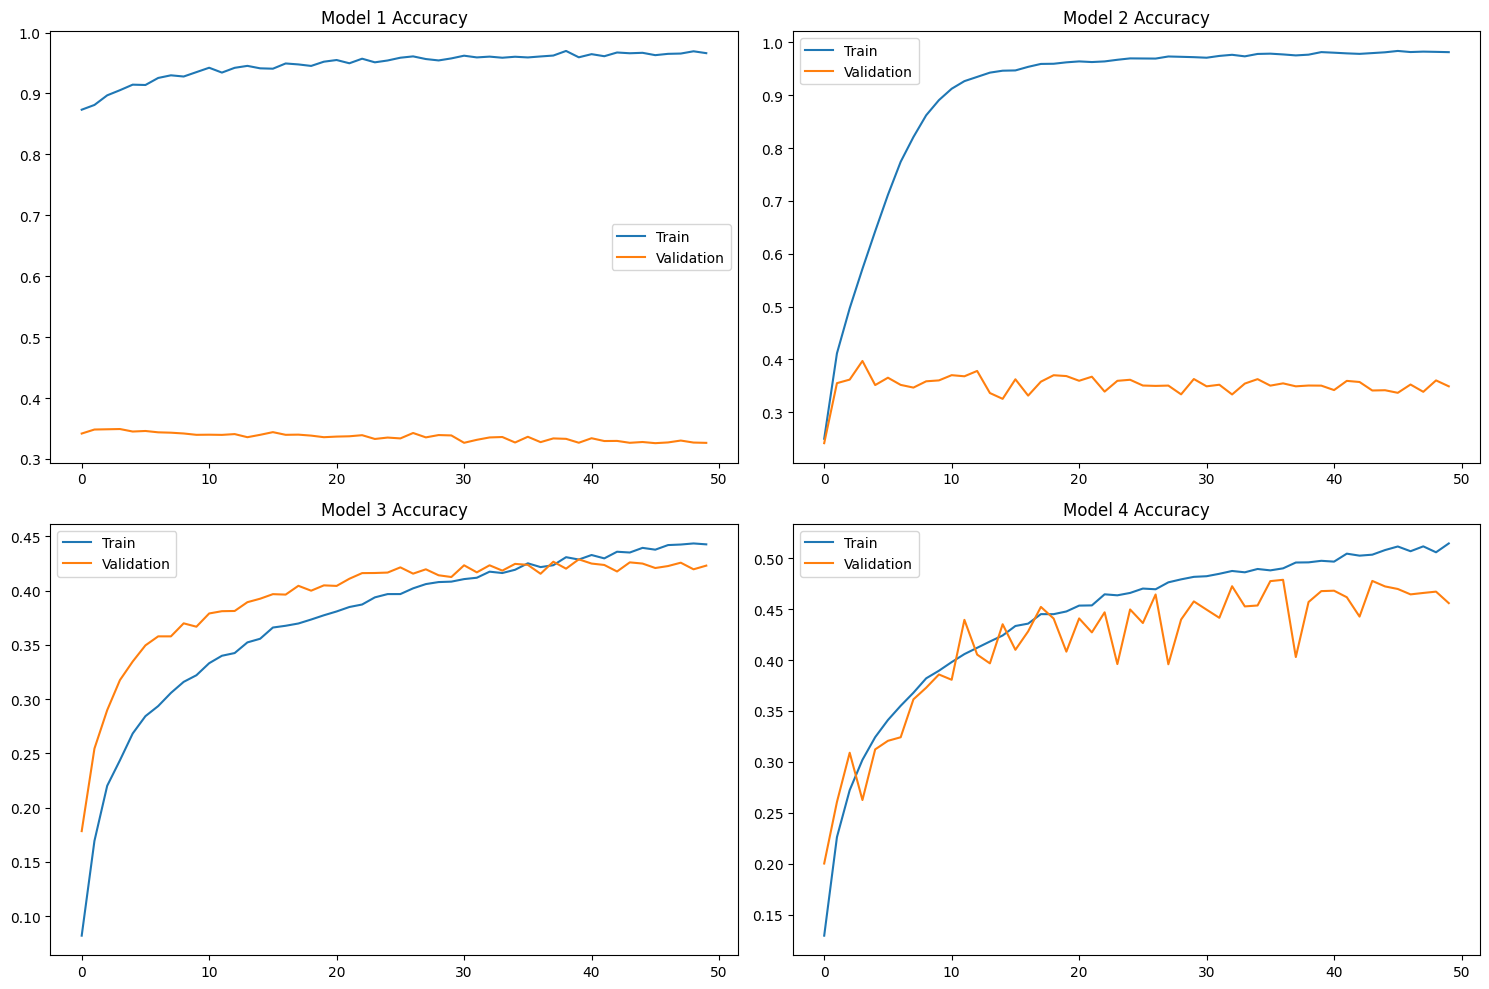

In [ ]:
plt.figure(figsize=(15,10))

# Графики для model_1
plt.subplot(2,2,1)
plt.plot(history_1.history['accuracy'], label='Train')
plt.plot(history_1.history['val_accuracy'], label='Validation')
plt.title('Model 1 Accuracy')
plt.legend()

# Графики для model_2
plt.subplot(2,2,2)
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Validation')
plt.title('Model 2 Accuracy')
plt.legend()

# Графики для model_3
plt.subplot(2,2,3)
plt.plot(history_3.history['accuracy'], label='Train')
plt.plot(history_3.history['val_accuracy'], label='Validation')
plt.title('Model 3 Accuracy')
plt.legend()

# Графики для model_4
plt.subplot(2,2,4)
plt.plot(history_4.history['accuracy'], label='Train')
plt.plot(history_4.history['val_accuracy'], label='Validation')
plt.title('Model 4 Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Ваши выводы

Первая помдель имеет высокий точность в тренировочных, но низкий в валидационных - модель переобучается.

Второй модели похожая ситуация, но валидационные чуть лучше. Ускорилось обучение, но не решило проблему переобучения.

У третьей отсутствует переобучение, и точность валидационных выросла.

Четвертая модель имеет наибольшее значение точности валидационных данных.

Ваш итог

Наихудшая модель: Model 1 (чистое переобучение).

Лучший потенциал для улучшения: Model 3 (Dropout).

Лучшая текущая модель: Model 4

### 1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_75']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


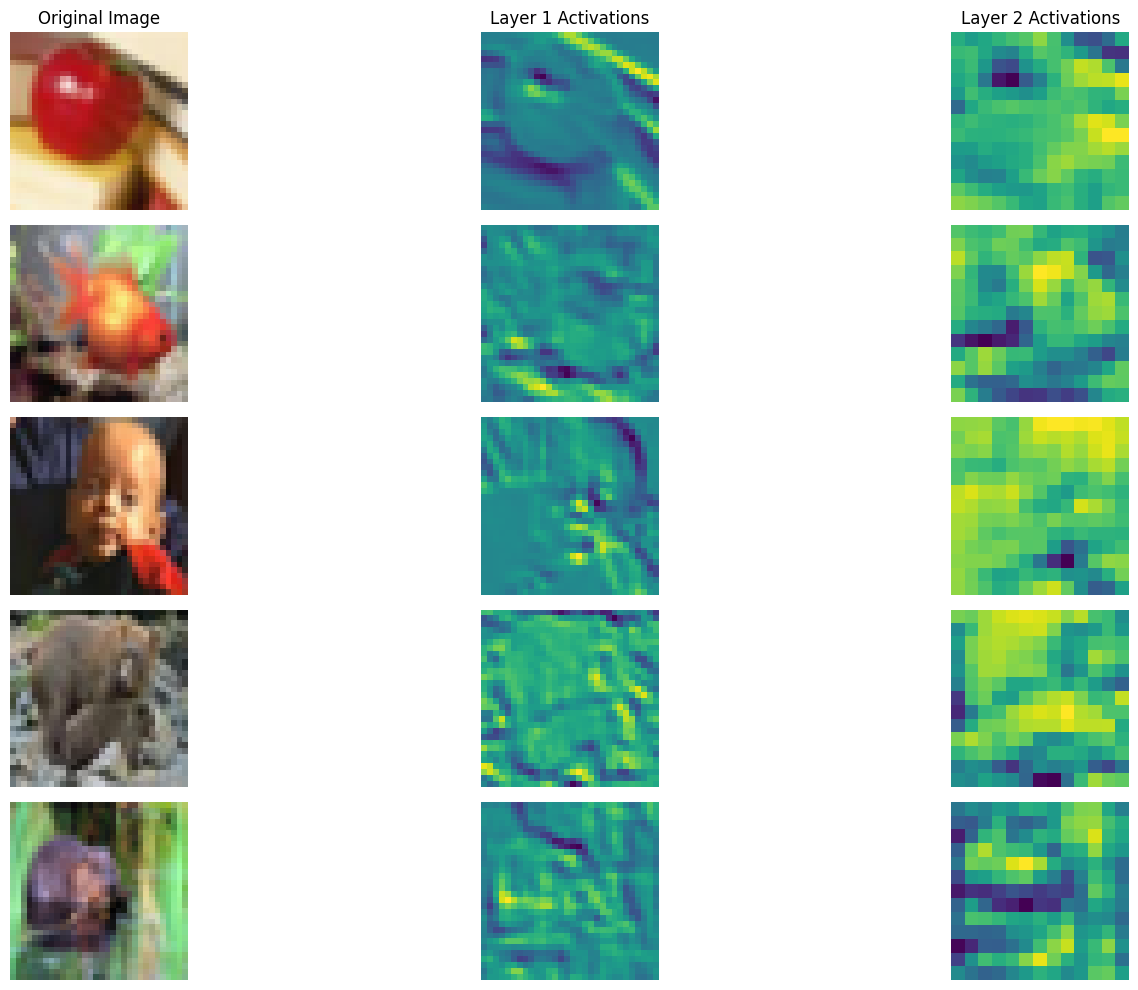

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Создаем модель для визуализации активаций
layer_outputs = [layer.output for layer in model_4.layers if 'conv' in layer.name][:3]  # Берем первые 3 сверточных слоя
activation_model = Model(inputs=model_4.inputs, outputs=layer_outputs)  # Используем .inputs вместо .input

# Выбираем 5 примеров из тестового набора
class_indices = [np.random.choice(np.where(y_test == i)[0]) for i in range(5)]

plt.figure(figsize=(20, 10))
for i, idx in enumerate(class_indices):
    # Препроцессинг изображения
    img = x_test[idx].reshape(1, 32, 32, 3)

    # Получаем активации
    activations = activation_model.predict(img, verbose=0)

    # Визуализируем оригинальное изображение
    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(x_test[idx])
    plt.axis('off')
    if i == 0:
        plt.title('Original Image')

    # Визуализируем активации для каждого слоя
    for layer_num, activation in enumerate(activations):
        plt.subplot(5, 4, i*4 + layer_num + 2)
        plt.imshow(activation[0, :, :, 0], cmap='viridis')  # Первый фильтр
        plt.axis('off')
        if i == 0:
            plt.title(f'Layer {layer_num+1} Activations')

plt.tight_layout()
plt.show()

## Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kausthubkannan/5-flower-types-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 242M/242M [00:12<00:00, 21.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kausthubkannan/5-flower-types-classification-dataset/versions/1


In [ ]:
dataset_path = f"{path}/flower_images"

In [ ]:
# Параметры
img_size = (150, 150)
batch_size = 32

# Генераторы данных
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [ ]:
from tensorflow.keras.models import load_model

try:
    basic_model = load_model('/basic_cnn_model.h5')
    previous_model = load_model('/flower_classifier.h5')
except:
    print("Ошибка")


In [ ]:
resnet_model = load_model('/resnet_inspired_model.h5')

In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dropout

def create_enhanced_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
        BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        Dropout(0.25),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        Dropout(0.25),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        Dropout(0.25),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512),
        BatchNormalization(),
        Dropout(0.5),
        tf.keras.layers.Dense(5, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

enhanced_model = create_enhanced_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = enhanced_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=15
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 312ms/step - accuracy: 0.4258 - loss: 2.6505 - val_accuracy: 0.2177 - val_loss: 1.5982
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 301ms/step - accuracy: 0.5619 - loss: 1.2478 - val_accuracy: 0.3800 - val_loss: 1.4183
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 301ms/step - accuracy: 0.5800 - loss: 1.0941 - val_accuracy: 0.4919 - val_loss: 1.2999
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 297ms/step - accuracy: 0.6196 - loss: 0.9887 - val_accuracy: 0.5565 - val_loss: 1.1561
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 320ms/step - accuracy: 0.6679 - loss: 0.8744 - val_accuracy: 0.5988 - val_loss: 1.0655
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 301ms/step - accuracy: 0.6799 - loss: 0.8527 - val_accuracy: 0.6562 - val_loss: 1.0992
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 301ms/step - accuracy: 0.6935 - loss: 0.7916 - val_accuracy: 0.6603 - val_loss: 0.9294
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 302ms/step - accuracy: 0.7194 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


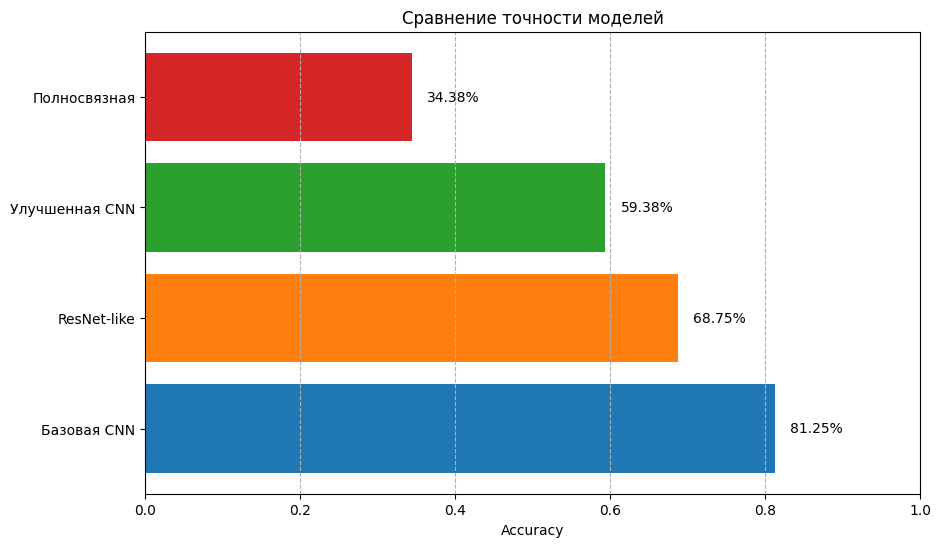

In [ ]:
import numpy as np
import cv2
from sklearn.metrics import accuracy_score

def preprocess_for_flower_classifier(images):
    """Подготовка данных для flower_classifier (64x64 -> flat vector)"""
    processed = []
    for img in images:
        # Убираем нормализацию (если изображения уже нормализованы)
        unnorm_img = img * 255.0
        # Изменяем размер и преобразуем в вектор
        resized = cv2.resize(unnorm_img, (64, 64)).flatten()
        # Новая нормализация
        processed.append(resized / 255.0)
    return np.array(processed)

# Загрузка тестовых данных
validation_generator.reset()
test_images, test_labels = next(validation_generator)
test_images = test_images[:32]
test_true = np.argmax(test_labels[:32], axis=1)

# Предсказания для каждой модели
preds = {
    'Базовая CNN': basic_model.predict(test_images).argmax(axis=1),
    'ResNet-like': resnet_model.predict(test_images).argmax(axis=1),
    'Улучшенная CNN': enhanced_model.predict(test_images).argmax(axis=1),
    'Полносвязная': previous_model.predict(
        preprocess_for_flower_classifier(test_images)
    ).argmax(axis=1)
}

# Расчет точности
results = {name: accuracy_score(test_true, pred) for name, pred in preds.items()}

# Визуализация результатов
plt.figure(figsize=(10,6))
plt.barh(list(results.keys()), list(results.values()), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.xlim(0, 1)
plt.title('Сравнение точности моделей')
plt.xlabel('Accuracy')
plt.grid(axis='x', linestyle='--')
for i, (name, acc) in enumerate(results.items()):
    plt.text(acc + 0.02, i, f"{acc:.2%}", va='center')
plt.show()

Визуализация активаций для 5 классов:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


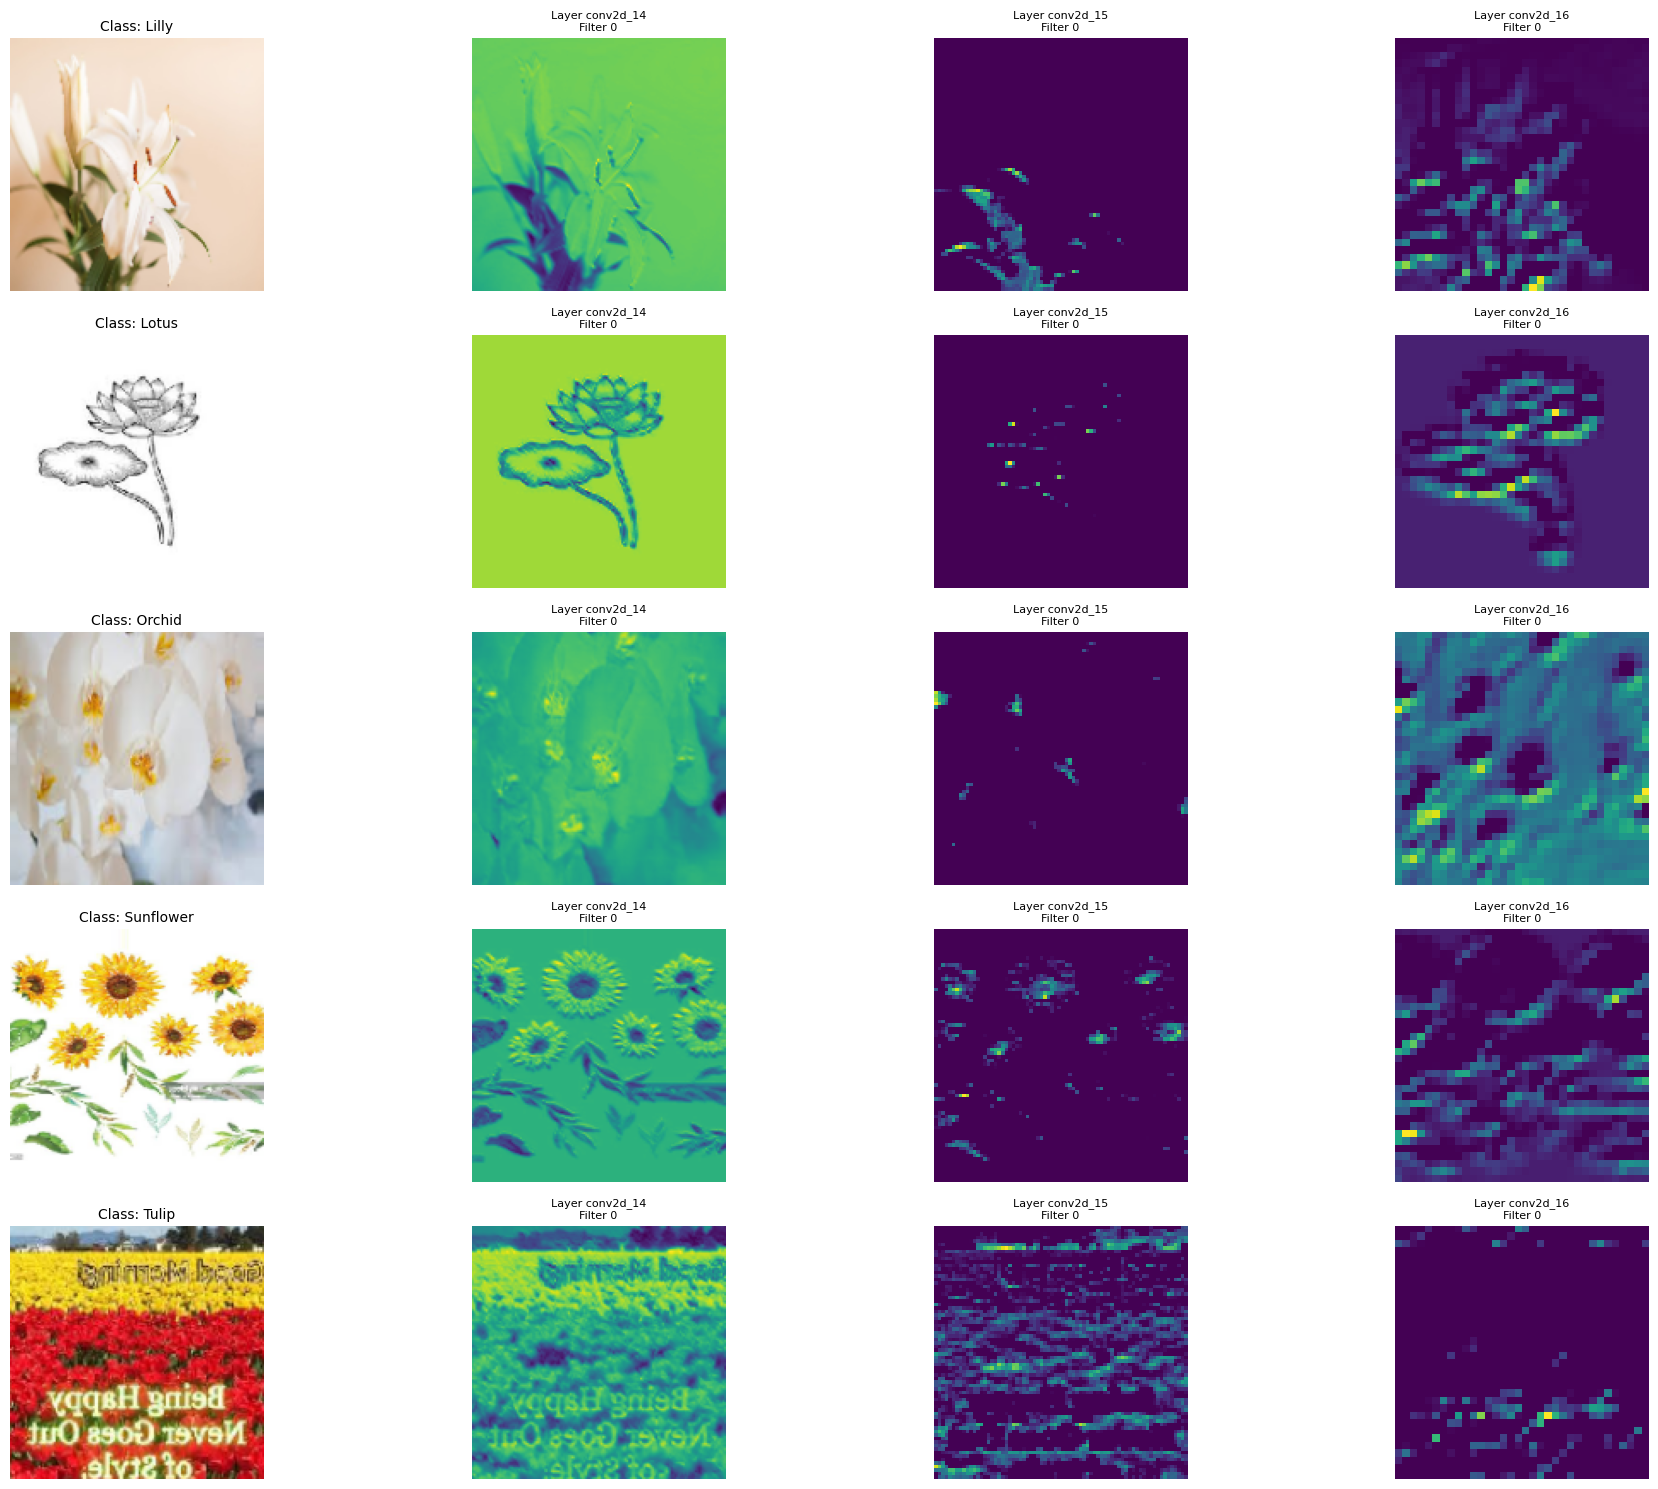

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Выбор по одному примеру из каждого класса
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())
selected_images = []
selected_labels = []

# Выбираем первые 5 классов
for class_id in range(5):
    # Находим индексы изображений нужного класса
    idx = np.where(np.argmax(test_labels, axis=1) == class_id)[0]
    # Берем первое подходящее изображение
    selected_images.append(test_images[idx[0]])
    selected_labels.append(class_names[class_id])

# 2. Модифицированная функция визуализации
def visualize_class_activations(model, images, class_names):
    # Находим все сверточные слои
    conv_layers = [layer for layer in model.layers
                  if isinstance(layer, tf.keras.layers.Conv2D)]

    if not conv_layers:
        print("Модель не содержит сверточных слоев!")
        return

    # Создаем модель для получения активаций
    outputs = [layer.output for layer in conv_layers[:3]]  # Первые 3 слоя
    activation_model = tf.keras.Model(inputs=model.inputs, outputs=outputs)

    plt.figure(figsize=(20, 15))

    for i, (img, class_name) in enumerate(zip(images, class_names)):
        # Получаем активации
        activations = activation_model.predict(np.expand_dims(img, axis=0))

        # Отображение оригинального изображения
        plt.subplot(5, 4, i*4 + 1)
        plt.imshow(img)
        plt.title(f"Class: {class_name}", fontsize=10)
        plt.axis('off')

        # Отображение активаций для каждого слоя
        for layer_idx, act in enumerate(activations):
            plt.subplot(5, 4, i*4 + layer_idx + 2)

            # Нормализация и выбор первого фильтра
            activation = act[0, :, :, 0]
            activation = (activation - activation.min()) / (activation.max() - activation.min() + 1e-8)

            plt.imshow(activation, cmap='viridis')
            plt.title(f"Layer {conv_layers[layer_idx].name}\nFilter 0", fontsize=8)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# 3. Проверка и визуализация
if len(selected_images) == 5:
    print("Визуализация активаций для 5 классов:")
    visualize_class_activations(enhanced_model, selected_images, selected_labels)
else:
    print("Ошибка: не удалось выбрать изображения для всех классов!")